In [5]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

In [6]:
df= pd.read_csv('cleaned_data.csv')

In [7]:
df.head() 

,participant_id,real_age,real_sex,nomotion_age,nomotion_sex,nomotion_handedness,nomotion_bmi,nomotion_fluid_intelligence,nomotion_neuroticism,motion_age,motion_sex,motion_handedness,motion_bmi,motion_fluid_intelligence,motion_neuroticism
0,sub-NC150,42,Male,35.724240,0.999888,0.002038,26.205930,0.423997,-0.006433,33.912937,0.999132,0.002312,25.666060,0.220162,0.016456
1,sub-NC183,28,Male,24.071867,0.993208,0.006977,21.673967,-0.016893,-0.101148,27.218252,0.999845,0.008577,22.249702,-0.087082,-0.053923
2,sub-NC188,52,Male,56.300518,0.999722,0.003651,24.680128,0.193321,-0.080030,52.371117,0.999355,0.007383,23.950453,0.037053,-0.131808
3,sub-NC189,56,Male,59.404533,0.978784,0.004347,24.910831,0.224922,-0.043789,58.310130,0.961742,0.003383,27.841696,-0.118790,0.052526
4,sub-NC216,27,Male,22.259346,0.135934,0.004544,25.788870,-0.000131,0.128404,28.275888,0.919534,0.004507,27.214000,-0.260030,0.153229


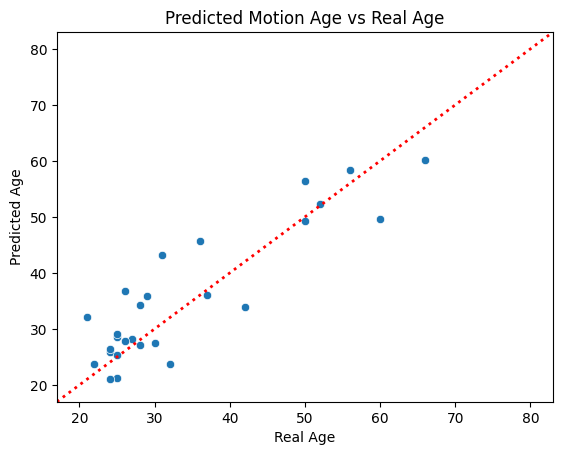

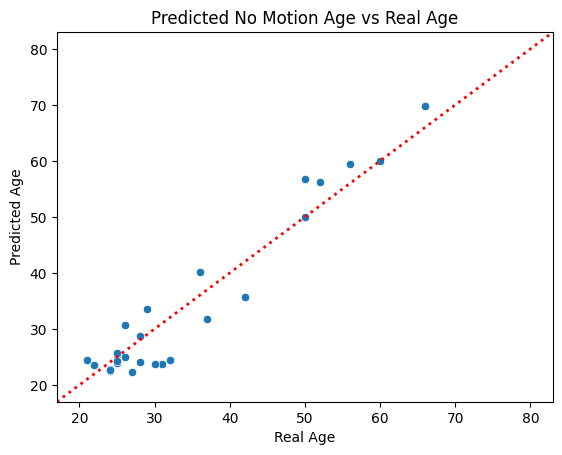

In [8]:
sns.scatterplot(
    x=df['real_age'],          # real age
    y=df['motion_age']        # predicted age
)

plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Predicted Motion Age vs Real Age")
plt.axline((20, 20), (80, 80), linewidth=2, linestyle='dotted',color='r',label='Unity line')

plt.show()

sns.scatterplot(
    x=df['real_age'],          # real age
    y=df['nomotion_age']        # predicted age
)

plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Predicted No Motion Age vs Real Age")
plt.axline((20, 20), (80, 80), linewidth=2, linestyle='dotted',color='r',label='Unity line')

plt.show()

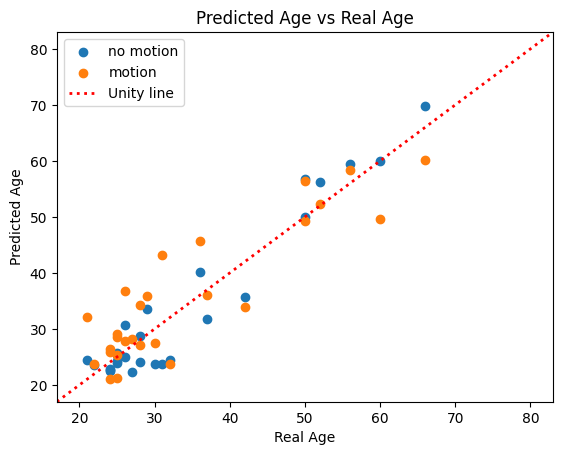

In [9]:
plt.scatter(
    x=df['real_age'],          # real age
    y=df['nomotion_age'],
    label='no motion'
)
plt.scatter(
    x=df['real_age'],          # real age
    y=df['motion_age'],
    label='motion'
)
plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Predicted Age vs Real Age")
plt.axline((20, 20), (80, 80), linewidth=2, linestyle='dotted',color='r',label='Unity line')
plt.legend()

plt.show()

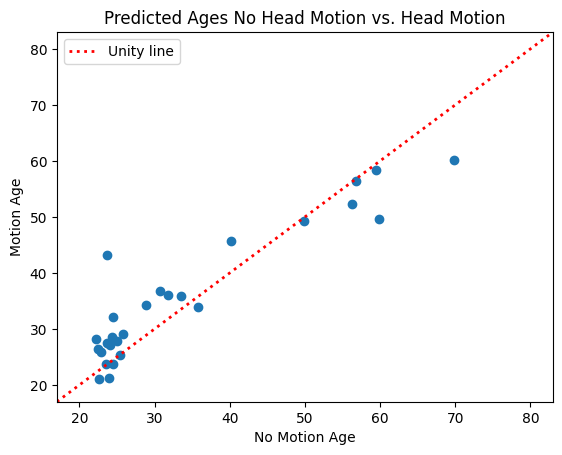

In [10]:
plt.scatter(x=df['nomotion_age'], y=df['motion_age'])

plt.xlabel("No Motion Age")
plt.ylabel("Motion Age")
plt.title("Predicted Ages No Head Motion vs. Head Motion")
plt.axline((20, 20), (80, 80), linewidth=2, linestyle='dotted',color='r',label='Unity line')
plt.legend()
plt.show()

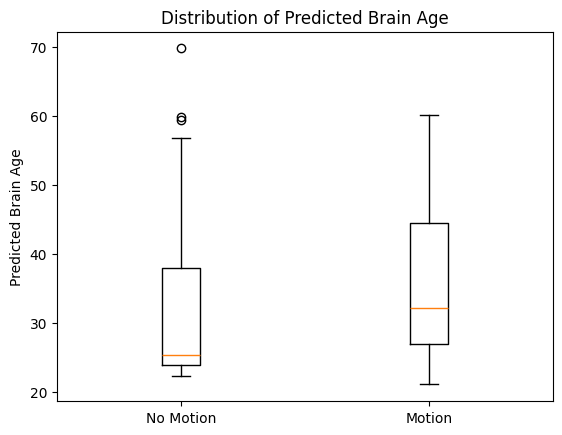

In [12]:
import matplotlib.pyplot as plt

plt.boxplot([df["nomotion_age"], df["motion_age"]])
plt.xticks([1,2], ["No Motion","Motion"])
plt.ylabel("Predicted Brain Age")
plt.title("Distribution of Predicted Brain Age")
plt.show()

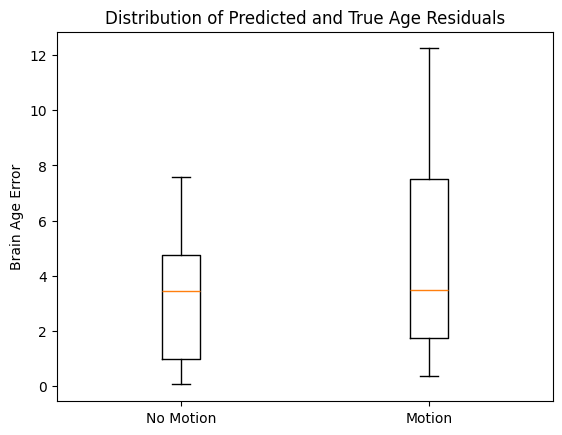

In [14]:
import matplotlib.pyplot as plt

error_motion=np.abs(df["real_age"]-df["motion_age"])
error_nomotion=np.abs(df["real_age"]-df["nomotion_age"])

plt.boxplot([error_nomotion, error_motion])
plt.xticks([1,2], ["No Motion","Motion"])
plt.ylabel("Brain Age Error")
plt.title("Distribution of Predicted and True Age Residuals")
plt.show()

In [17]:
MAE_nomotion=np.mean(np.abs(df['real_age']-df['nomotion_age']))
MAE_motion=np.mean(np.abs(df['real_age']-df['motion_age']))

In [18]:
print('MAE No Motion:  ' + str(MAE_nomotion))
print('MAE Motion:  ' + str(MAE_motion))

MAE No Motion:  3.2230126666666656
MAE Motion:  4.729198074074075


In [22]:
#Significance of effect of motion on residual: 
from scipy import stats
from scipy.stats import wilcoxon


t_stat, p_val = stats.ttest_rel(error_motion, error_nomotion, alternative='greater')

print("Prediction error comparison")
print("t =", t_stat)
print("p =", p_val)

Prediction error comparison
t = 2.1489166347793742
p = 0.02056299334618738


In [23]:
#Wilcoxon test for error: 

stat, p = wilcoxon(error_motion, error_nomotion, alternative='greater')

print("Wilcoxon error test")
print("W =", stat)
print("p =", p)

Wilcoxon error test
W = 272.0
p = 0.023131288588047028


Prediction error is significantly different between motion and no-motion scans. Since one sided t-test this implies that error is motion age is significnatly greater than error in no motion.

In [24]:
#Significance of testing bias caused by motion (positive or negative): 
t_stat, p_val = stats.ttest_rel(df["motion_age"], df["nomotion_age"])

print("Paired t-test")
print("t =", t_stat)
print("p =", p_val)

Paired t-test
t = 1.6531948663224134
p = 0.11031720503962116


In [25]:


stat, p = wilcoxon(df["motion_age"], df["nomotion_age"])

print("Wilcoxon bias test")
print("W =", stat)
print("p =", p)

Wilcoxon bias test
W = 110.0
p = 0.05847424268722534


Not statistically signfiicant, head motion does not signficiantly bias younger or older age predictions. 

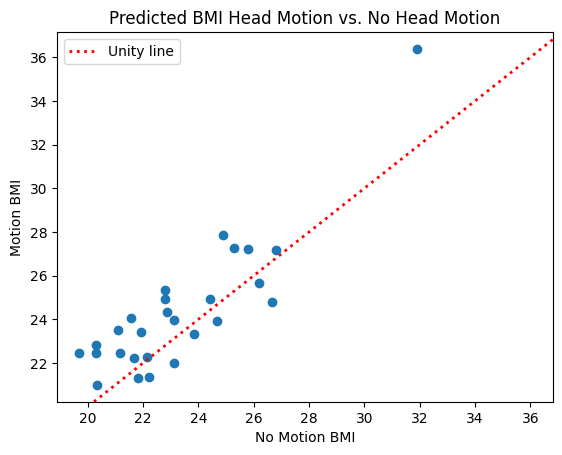

In [99]:
plt.scatter(x=df['nomotion_bmi'], y=df['motion_bmi'])

plt.xlabel("No Motion BMI")
plt.ylabel("Motion BMI")
plt.title("Predicted BMI Head Motion vs. No Head Motion")
plt.axline((35, 35), (36, 36),
           linewidth=2,
           linestyle='dotted',
           color='r',
           label='Unity line')
plt.legend()
plt.show()

In [35]:
#Repeated procedures for BMI, Neuroticism, fluid intelligence (Continuous variables): 
t_stat, p_val = stats.ttest_rel(df["motion_bmi"], df["nomotion_bmi"], alternative="greater")

print("Paired t-test")
print("t =", t_stat)
print("p =", p_val)

bmi_bias = df["motion_bmi"] - df["nomotion_bmi"]

stat, p = wilcoxon(bmi_bias, alternative="greater")

print("Wilcoxon bias test")
print("W =", stat)
print("p =", p)



Paired t-test
t = 3.697512146879573
p = 0.0005118428905323852
Wilcoxon bias test
W = 316.0
p = 0.000764705240726471


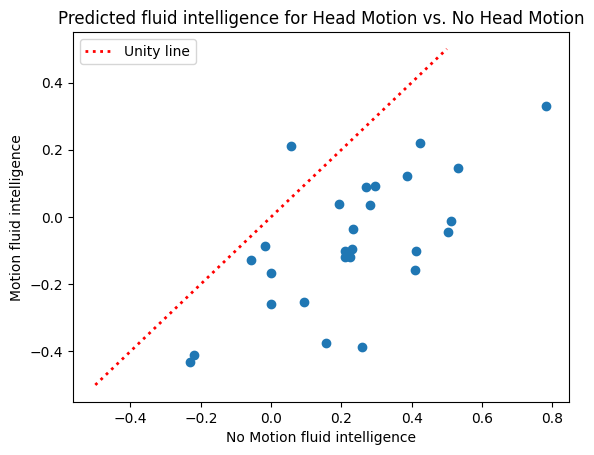

In [100]:
plt.scatter(x=df['nomotion_fluid_intelligence'], y=df['motion_fluid_intelligence'])

plt.xlabel("No Motion fluid intelligence")
plt.ylabel("Motion fluid intelligence")
plt.title("Predicted fluid intelligence for Head Motion vs. No Head Motion")
plt.plot([-0.5, 0.5], [-0.5, 0.5],
         linewidth=2,
         linestyle='dotted',
         color='r',
         label='Unity line')
plt.legend()
plt.show()

In [9]:
t_stat, p_val =stats.ttest_rel(df["motion_fluid_intelligence"], df["nomotion_fluid_intelligence"],alternative="less")

print("Paired t-test")
print("t =", t_stat)
print("p =", p_val)

fi_bias = df["motion_fluid_intelligence"] - df["nomotion_fluid_intelligence"]

stat, p = wilcoxon(fi_bias,alternative="less")

print("Wilcoxon bias test")
print("W =", stat)
print("p =", p)

Paired t-test
t = -8.683536202709636
p = 1.8379063243094895e-09
Wilcoxon bias test
W = 3.0
p = 3.725290298461914e-08


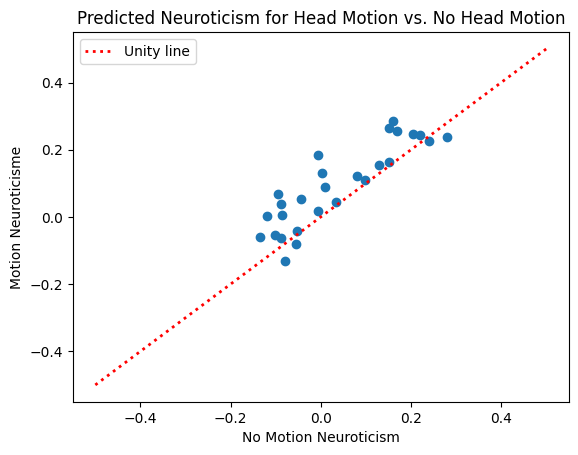

In [104]:
plt.scatter(x=df['nomotion_neuroticism'], y=df['motion_neuroticism'])

plt.xlabel("No Motion Neuroticism")
plt.ylabel("Motion Neuroticisme")
plt.title("Predicted Neuroticism for Head Motion vs. No Head Motion")
plt.plot([-0.5, 0.5], [-0.5, 0.5],
         linewidth=2,
         linestyle='dotted',
         color='r',
         label='Unity line')
plt.legend()
plt.show()

In [34]:
t_stat, p_val = stats.ttest_rel(df["motion_neuroticism"], df["nomotion_neuroticism"], alternative="greater")

print("Paired t-test")
print("t =", t_stat)
print("p =", p_val)

neuroticism_bias = df["motion_neuroticism"] - df["nomotion_neuroticism"]

stat, p = wilcoxon(neuroticism_bias, alternative="greater")

print("Wilcoxon bias test")
print("W =", stat)
print("p =", p)

Paired t-test
t = 4.780994184739057
p = 2.9955177342082585e-05
Wilcoxon bias test
W = 340.0
p = 4.798173904418945e-05


Head motion signficiantly biased a higher neuroticism, and BMI prediction, and a lower fluid intelligence. 

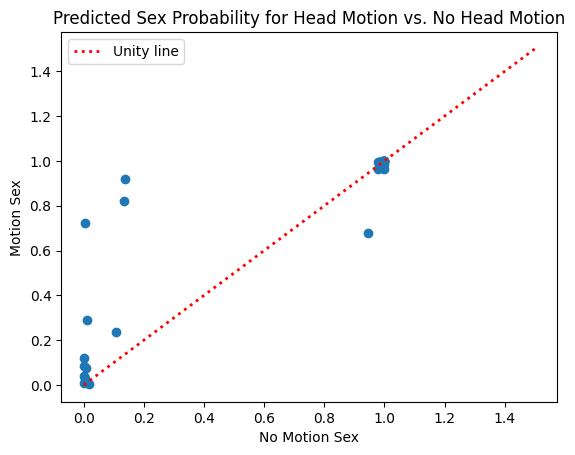

In [105]:
plt.scatter(x=df['nomotion_sex'], y=df['motion_sex'])

plt.xlabel("No Motion Sex")
plt.ylabel("Motion Sex")
plt.title("Predicted Sex Probability for Head Motion vs. No Head Motion")
plt.plot([0, 1.5], [0, 1.5],
         linewidth=2,
         linestyle='dotted',
         color='r',
         label='Unity line')
plt.legend()
plt.show()

In [70]:
t_stat, p_val = stats.ttest_rel(df["motion_sex"], df["nomotion_sex"], alternative="greater")

print("Paired t-test")
print("t =", t_stat)
print("p =", p_val)

neuroticism_bias = df["motion_sex"] - df["nomotion_sex"]

stat, p = wilcoxon(neuroticism_bias, alternative="greater")

print("Wilcoxon bias test")
print("W =", stat)
print("p =", p)

Paired t-test
t = 2.087917867074484
p = 0.023373016948804382
Wilcoxon bias test
W = 288.0
p = 0.008095011115074158


Predicted greater probability for sex in motion vs in nomotion, motion will bias a specific sex. 

In [26]:
from sklearn.metrics import roc_auc_score
df['real_sex_encoded'] = df['real_sex'].map({'Female': 0, 'Male': 1})

In [27]:
#Encoding with 0.5
df['nomotion_pred_class'] = (df['nomotion_sex'] >= 0.5).astype(int)
df['motion_pred_class'] = (df['motion_sex'] >= 0.5).astype(int)

In [28]:
df['nomotion_correct'] = df['nomotion_pred_class'] == df['real_sex_encoded']
df['motion_correct'] = df['motion_pred_class'] == df['real_sex_encoded']
a = np.sum((df['motion_correct'] == True) & (df['nomotion_correct'] == True))
b = np.sum((df['motion_correct'] == True) & (df['nomotion_correct'] == False))
c = np.sum((df['motion_correct'] == False) & (df['nomotion_correct'] == True))
d = np.sum((df['motion_correct'] == False) & (df['nomotion_correct'] == False))

contingency = np.array([
    [a, b],
    [c, d]
])
from statsmodels.stats.contingency_tables import mcnemar
result = mcnemar(contingency, exact=False, correction=True)

print("Statistic:", result.statistic)
print("p-value:", result.pvalue)

Statistic: 0.0
p-value: 1.0


In [25]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# No-motion group
cm_nomotion = confusion_matrix(df['real_sex_encoded'], df['nomotion_pred_class'])
print("Confusion Matrix (No Motion):\n", cm_nomotion)

# Motion group
cm_motion = confusion_matrix(df['real_sex_encoded'], df['motion_pred_class'])
print("Confusion Matrix (Motion):\n", cm_motion)

# Function to pretty-print
def print_confusion(cm, group_name):
    cm_df = pd.DataFrame(cm,
                         index=['Actual 0 (Female)', 'Actual 1 (Male)'],
                         columns=['Predicted 0', 'Predicted 1'])
    print(f"\nConfusion Matrix ({group_name}):\n", cm_df)

print_confusion(cm_nomotion, "No Motion")
print_confusion(cm_motion, "Motion")

Confusion Matrix (No Motion):
 [[11  0]
 [ 1 15]]
Confusion Matrix (Motion):
 [[ 9  2]
 [ 0 16]]

Confusion Matrix (No Motion):
                    Predicted 0  Predicted 1
Actual 0 (Female)           11            0
Actual 1 (Male)              1           15

Confusion Matrix (Motion):
                    Predicted 0  Predicted 1
Actual 0 (Female)            9            2
Actual 1 (Male)              0           16


In [26]:
accuracy_nomotion = (cm_nomotion[0,0] + cm_nomotion[1,1]) / cm_nomotion.sum()
accuracy_motion = (cm_motion[0,0] + cm_motion[1,1]) / cm_motion.sum()

print(f"Accuracy (No Motion): {accuracy_nomotion:.3f}")
print(f"Accuracy (Motion): {accuracy_motion:.3f}")

Accuracy (No Motion): 0.963
Accuracy (Motion): 0.926
